# Pipeline de conversion de senales magneticas (LibriBrain -> entrenamiento)

Este cuaderno muestra **paso a paso** como pasa una muestra desde LibriBrain hasta la entrada al modelo.

Cada paso incluye al menos una visualizacion y/o una tabla pequena con forma y estadisticas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from IPython.display import display

from meg_transfer_learning_libribrain import (
    LibriBrainConfig,
    load_libribrain,
    MEGPreprocessor,
    MEGImageModelEndToEnd,
)
from meg_gpu_cwt import CWTLayer, zscore_scalogram

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_grad_enabled(False)

TASK = "phoneme"       # "phoneme" o "speech"
DATA_PATH = "./libribrain_data"
SAMPLE_IDX = 0
N_FREQS = 96
IMG_SIZE = 224
SFREQ = 250.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def describe_array(name, x):
    arr = to_numpy(x)
    return pd.DataFrame([
        {
            "tensor": name,
            "shape": str(arr.shape),
            "dtype": str(arr.dtype),
            "min": float(np.nanmin(arr)),
            "max": float(np.nanmax(arr)),
            "mean": float(np.nanmean(arr)),
            "std": float(np.nanstd(arr)),
        }
    ])


def label_to_scalar(raw_label, threshold=0.5):
    if isinstance(raw_label, torch.Tensor):
        if raw_label.numel() == 1:
            return int(raw_label.item())
        return int(raw_label.float().mean().item() >= threshold)

    arr = np.asarray(raw_label)
    if arr.size == 1:
        return int(arr.reshape(-1)[0])
    return int(arr.astype(np.float32).mean() >= threshold)

/home/odra/miniconda3/envs/scrabrain/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Dispositivo: cuda
Device: cuda


## Paso 1: Cargar una muestra desde LibriBrain (señal cruda)

[INFO] Cargando LibriBrain – tarea: phoneme, partición: train
[INFO] Dataset cargado: 1596956 samples, 39 clases, 306 canales
Sample idx: 0 | task: phoneme | label escalar: 2
n_classes=39, n_channels=306, T=125


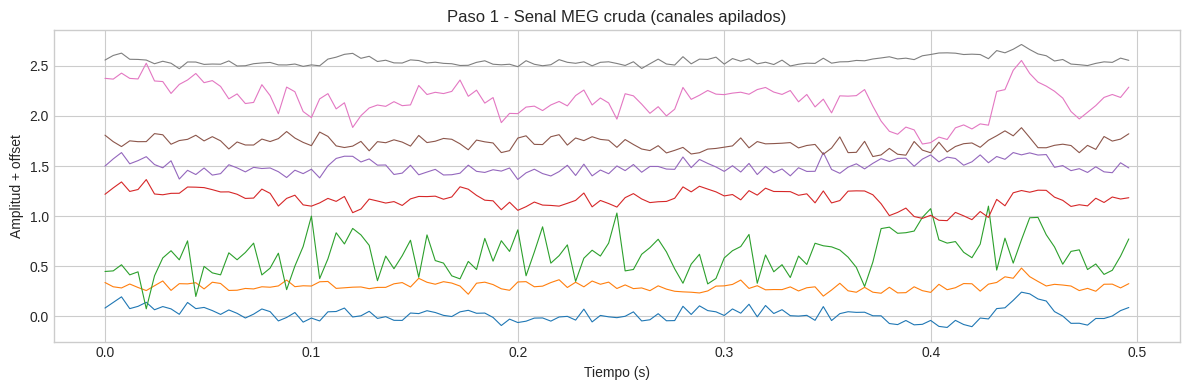

,tensor,shape,dtype,min,max,mean,std
0,epoch_raw,"(306, 125)",float32,-1.075429,2.081153,0.003883,0.113006


In [2]:
try:
    train_pnpl, n_classes, n_channels = load_libribrain(
        LibriBrainConfig(data_path=DATA_PATH, task=TASK, partition="train", download=False)
    )
except Exception:
    train_pnpl, n_classes, n_channels = load_libribrain(
        LibriBrainConfig(data_path=DATA_PATH, task=TASK, partition="train", download=True)
    )

raw_epoch, raw_label = train_pnpl[SAMPLE_IDX]
epoch_raw = np.asarray(raw_epoch, dtype=np.float32)  # (306, T)
label_scalar = label_to_scalar(raw_label)

print(f"Sample idx: {SAMPLE_IDX} | task: {TASK} | label escalar: {label_scalar}")
print(f"n_classes={n_classes}, n_channels={n_channels}, T={epoch_raw.shape[1]}")

time_s = np.arange(epoch_raw.shape[1]) / SFREQ
n_plot = min(8, epoch_raw.shape[0])
offset = 3.0 * np.std(epoch_raw[:n_plot])
offset = float(offset if offset > 1e-8 else 1.0)

plt.figure(figsize=(12, 4))
for ch in range(n_plot):
    plt.plot(time_s, epoch_raw[ch] + ch * offset, linewidth=0.8)
plt.title("Paso 1 - Senal MEG cruda (canales apilados)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud + offset")
plt.tight_layout()
plt.show()

display(describe_array("epoch_raw", epoch_raw))

## Paso 2: Preprocesado por epoch (instance norm y clip de outliers)

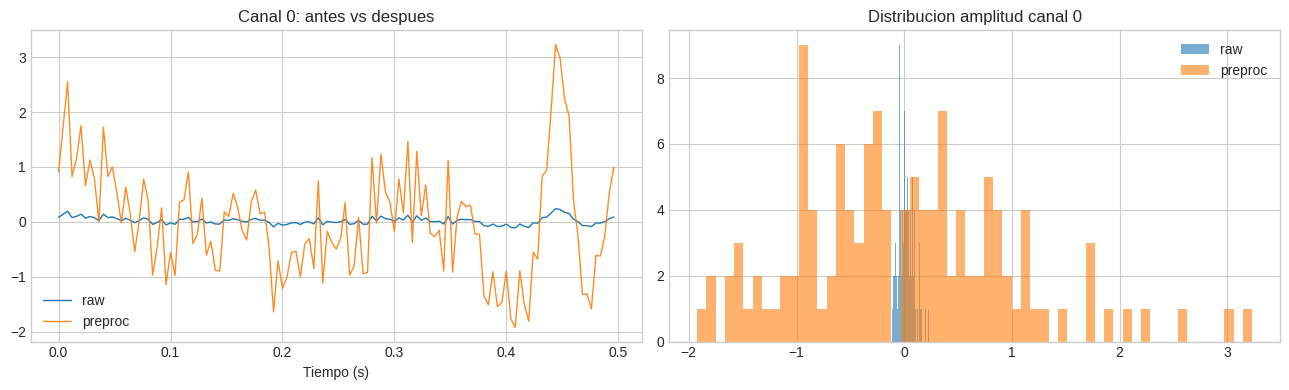

,tensor,shape,dtype,min,max,mean,std
0,epoch_raw,"(306, 125)",float32,-1.075429,2.081153,0.003883,0.113006
1,epoch_proc,"(306, 125)",float32,-5.000000,5.000000,-0.000031,0.999828


In [3]:
preprocessor = MEGPreprocessor(use_instance_norm=True, baseline_samples=None, clip_std=5.0)
epoch_proc = preprocessor(epoch_raw.copy())

ch = 0
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(time_s, epoch_raw[ch], label="raw", linewidth=1.0)
axes[0].plot(time_s, epoch_proc[ch], label="preproc", linewidth=1.0, alpha=0.9)
axes[0].set_title(f"Canal {ch}: antes vs despues")
axes[0].set_xlabel("Tiempo (s)")
axes[0].legend()

axes[1].hist(epoch_raw[ch], bins=60, alpha=0.6, label="raw")
axes[1].hist(epoch_proc[ch], bins=60, alpha=0.6, label="preproc")
axes[1].set_title(f"Distribucion amplitud canal {ch}")
axes[1].legend()

plt.tight_layout()
plt.show()

df_step2 = pd.concat([
    describe_array("epoch_raw", epoch_raw),
    describe_array("epoch_proc", epoch_proc),
], ignore_index=True)
display(df_step2)

## Paso 3: CWT (senal -> escalograma tiempo-frecuencia)

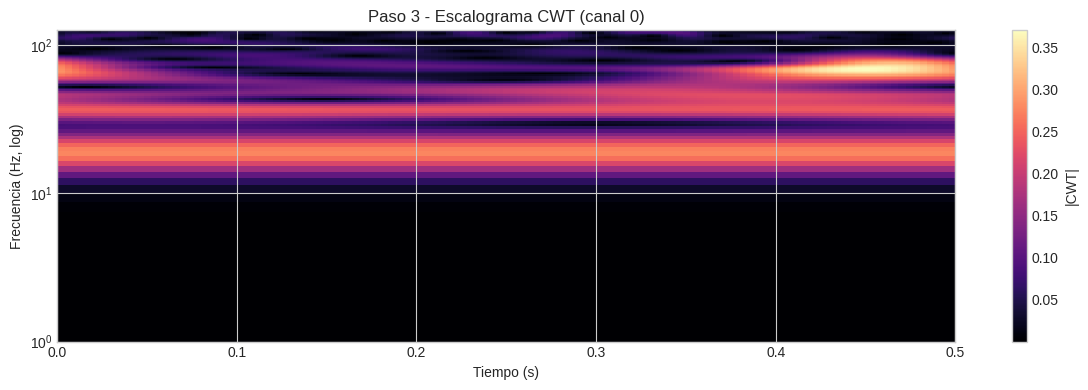

,tensor,shape,dtype,min,max,mean,std
0,scalogram,"(1, 306, 96, 125)",float32,9.617231e-09,0.80815,0.105975,0.102765


In [4]:
cwt_layer = CWTLayer(
    sfreq=SFREQ,
    n_freqs=N_FREQS,
    f_min=1.0,
    f_max=125.0,
    B=1.5,
    C=1.0,
).to(DEVICE)

x_epoch = torch.from_numpy(epoch_proc).unsqueeze(0).to(DEVICE)  # (1, 306, T)
scalogram = cwt_layer(x_epoch).cpu()  # (1, 306, F, T)

freqs = np.logspace(np.log10(1.0), np.log10(125.0), N_FREQS)
channel_to_show = 0
scg = scalogram[0, channel_to_show].numpy()  # (F, T)

plt.figure(figsize=(12, 4))
plt.imshow(
    scg,
    aspect="auto",
    origin="lower",
    extent=[0, epoch_raw.shape[1] / SFREQ, freqs[0], freqs[-1]],
    cmap="magma",
)
plt.yscale("log")
plt.colorbar(label="|CWT|")
plt.title(f"Paso 3 - Escalograma CWT (canal {channel_to_show})")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz, log)")
plt.tight_layout()
plt.show()

display(describe_array("scalogram", scalogram))

## Paso 4: Normalizacion del escalograma (z-score por banda)

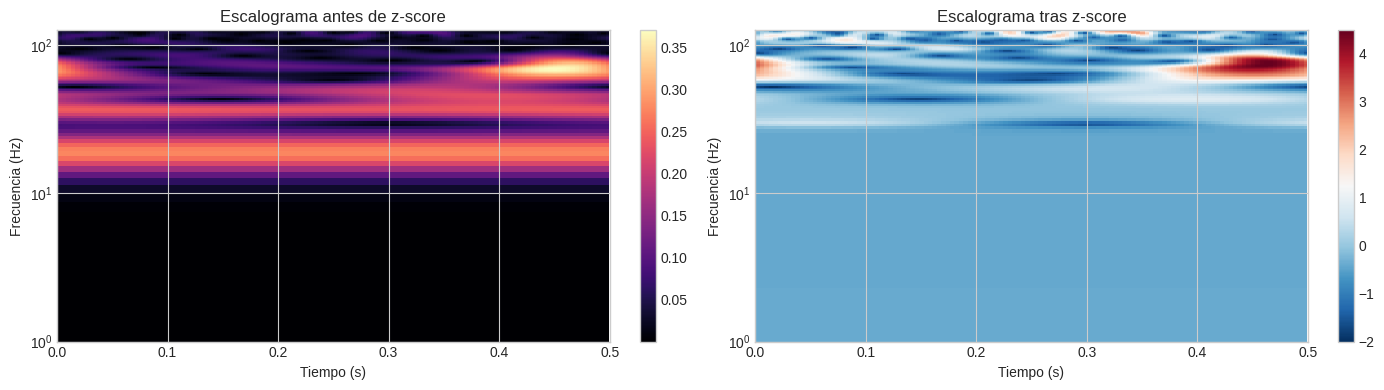

,tensor,shape,dtype,min,max,mean,std
0,scalogram,"(1, 306, 96, 125)",float32,9.617231e-09,0.808150,1.059751e-01,0.102765
1,scalogram_z,"(1, 306, 96, 125)",float32,-2.110579e+00,6.781643,4.893450e-08,0.998865


In [5]:
scalogram_z = zscore_scalogram(scalogram)

scg_raw = scalogram[0, channel_to_show].numpy()
scg_z = scalogram_z[0, channel_to_show].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im0 = axes[0].imshow(
    scg_raw,
    aspect="auto",
    origin="lower",
    extent=[0, epoch_raw.shape[1] / SFREQ, freqs[0], freqs[-1]],
    cmap="magma",
)
axes[0].set_yscale("log")
axes[0].set_title("Escalograma antes de z-score")
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Frecuencia (Hz)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    scg_z,
    aspect="auto",
    origin="lower",
    extent=[0, epoch_raw.shape[1] / SFREQ, freqs[0], freqs[-1]],
    cmap="RdBu_r",
)
axes[1].set_yscale("log")
axes[1].set_title("Escalograma tras z-score")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Frecuencia (Hz)")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

df_step4 = pd.concat([
    describe_array("scalogram", scalogram),
    describe_array("scalogram_z", scalogram_z),
], ignore_index=True)
display(df_step4)

## Paso 5: Proyeccion 306 -> 3 canales con `SensorMixer` (conv 1x1)

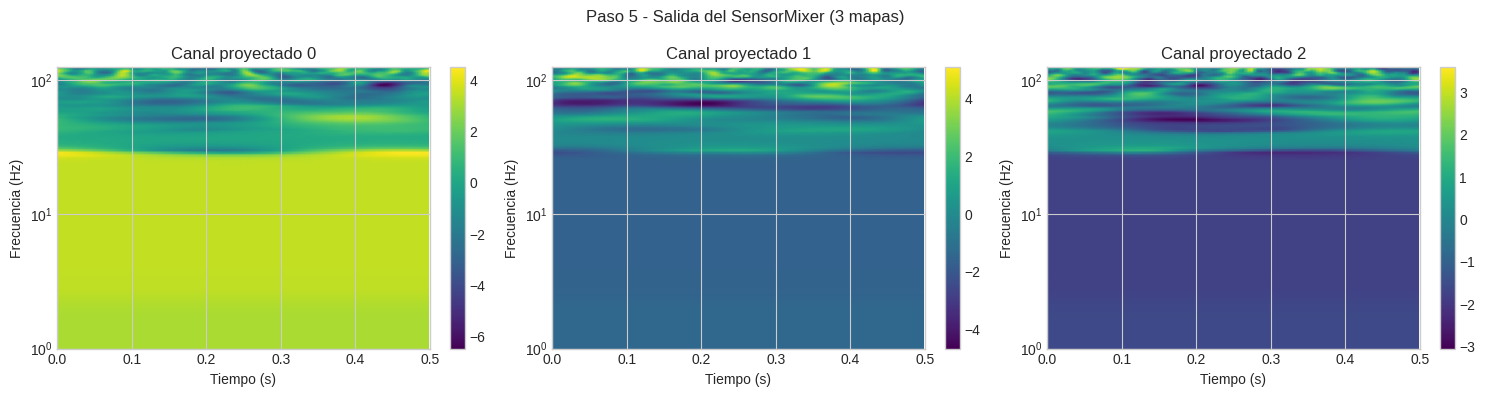

,tensor,shape,dtype,min,max,mean,std
0,rgb_maps,"(1, 3, 96, 125)",float32,-6.455716,5.09902,-0.052348,1.662506


In [6]:
model = MEGImageModelEndToEnd(
    backbone_name="resnet18",
    n_classes=n_classes,
    n_meg_channels=306,
    n_freqs=N_FREQS,
    img_size=IMG_SIZE,
    pretrained=False,  # evita descarga de pesos en esta demo
    strategy="frozen",
).to(DEVICE).eval()

rgb_maps = model.sensor_mixer(scalogram_z.to(DEVICE)).cpu()  # (1, 3, F, T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    im = axes[i].imshow(
        rgb_maps[0, i].numpy(),
        aspect="auto",
        origin="lower",
        extent=[0, epoch_raw.shape[1] / SFREQ, freqs[0], freqs[-1]],
        cmap="viridis",
    )
    axes[i].set_yscale("log")
    axes[i].set_title(f"Canal proyectado {i}")
    axes[i].set_xlabel("Tiempo (s)")
    axes[i].set_ylabel("Frecuencia (Hz)")
    fig.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle("Paso 5 - Salida del SensorMixer (3 mapas)")
plt.tight_layout()
plt.show()

display(describe_array("rgb_maps", rgb_maps))

## Paso 6: Resize a 224x224 y normalizacion ImageNet

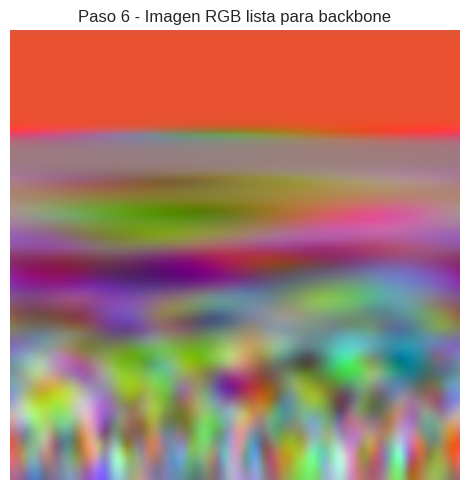

,tensor,shape,dtype,min,max,mean,std
0,rgb_resized,"(1, 3, 224, 224)",float32,-6.433591,4.999224,-0.052365,1.653479
1,rgb_01,"(1, 3, 224, 224)",float32,0.000000,1.000000,0.496728,0.201872
2,rgb_norm,"(1, 3, 224, 224)",float32,-2.117904,2.640000,0.208249,0.836473


In [7]:
rgb_resized = F.interpolate(
    rgb_maps,
    size=(IMG_SIZE, IMG_SIZE),
    mode="bilinear",
    align_corners=False,
)

img_min = rgb_resized.amin(dim=(2, 3), keepdim=True)
img_max = rgb_resized.amax(dim=(2, 3), keepdim=True)
rgb_01 = (rgb_resized - img_min) / (img_max - img_min + 1e-8)

imagenet_mean = torch.tensor([0.485, 0.456, 0.406], dtype=rgb_01.dtype).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225], dtype=rgb_01.dtype).view(1, 3, 1, 1)
rgb_norm = (rgb_01 - imagenet_mean) / imagenet_std

rgb_img = rgb_01[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(np.clip(rgb_img, 0, 1))
plt.title("Paso 6 - Imagen RGB lista para backbone")
plt.axis("off")
plt.tight_layout()
plt.show()

df_step6 = pd.concat([
    describe_array("rgb_resized", rgb_resized),
    describe_array("rgb_01", rgb_01),
    describe_array("rgb_norm", rgb_norm),
], ignore_index=True)
display(df_step6)

## Paso 7: Entrada al modelo y logits de salida

In [8]:
with torch.no_grad():
    logits = model(scalogram_z.to(DEVICE))  # el modelo aplica SensorMixer + resize + backbone

probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
top_k = min(10, n_classes)
top_idx = np.argsort(probs)[::-1][:top_k]

pred_table = pd.DataFrame({
    "rank": np.arange(1, top_k + 1),
    "class_idx": top_idx,
    "prob": probs[top_idx],
})

print("Nota: este ejemplo usa pesos aleatorios (pretrained=False), por eso las probabilidades son solo demostrativas.")
display(describe_array("logits", logits.cpu()))
display(pred_table)

Nota: este ejemplo usa pesos aleatorios (pretrained=False), por eso las probabilidades son solo demostrativas.


,tensor,shape,dtype,min,max,mean,std
0,logits,"(1, 39)",float32,-1.300753,1.041111,0.018456,0.466318


,rank,class_idx,prob
0,1,9,0.064310
1,2,18,0.047376
2,3,28,0.046092
3,4,15,0.043897
4,5,24,0.037812
5,6,16,0.037171
6,7,23,0.036967
7,8,31,0.035329
8,9,11,0.032794
9,10,20,0.031641


## Resumen de transformaciones (shapes)

Tabla compacta con la ruta completa de conversion.

In [9]:
shape_summary = pd.DataFrame([
    {"paso": "1. LibriBrain raw", "tensor": "epoch_raw", "shape": str(epoch_raw.shape), "descripcion": "senal MEG por sample"},
    {"paso": "2. Preprocess", "tensor": "epoch_proc", "shape": str(epoch_proc.shape), "descripcion": "instance norm + clip"},
    {"paso": "3. CWT", "tensor": "scalogram", "shape": str(tuple(scalogram.shape)), "descripcion": "(B, 306, F, T)"},
    {"paso": "4. Z-score", "tensor": "scalogram_z", "shape": str(tuple(scalogram_z.shape)), "descripcion": "normalizacion por banda"},
    {"paso": "5. SensorMixer", "tensor": "rgb_maps", "shape": str(tuple(rgb_maps.shape)), "descripcion": "306 -> 3 canales"},
    {"paso": "6. Resize", "tensor": "rgb_resized", "shape": str(tuple(rgb_resized.shape)), "descripcion": "(B, 3, 224, 224)"},
    {"paso": "7. ImageNet norm", "tensor": "rgb_norm", "shape": str(tuple(rgb_norm.shape)), "descripcion": "input normalizado"},
    {"paso": "8. Modelo", "tensor": "logits", "shape": str(tuple(logits.shape)), "descripcion": "salida para CrossEntropy"},
])

display(shape_summary)

,paso,tensor,shape,descripcion
0,1. LibriBrain raw,epoch_raw,"(306, 125)",senal MEG por sample
1,2. Preprocess,epoch_proc,"(306, 125)",instance norm + clip
2,3. CWT,scalogram,"(1, 306, 96, 125)","(B, 306, F, T)"
3,4. Z-score,scalogram_z,"(1, 306, 96, 125)",normalizacion por banda
4,5. SensorMixer,rgb_maps,"(1, 3, 96, 125)",306 -> 3 canales
5,6. Resize,rgb_resized,"(1, 3, 224, 224)","(B, 3, 224, 224)"
6,7. ImageNet norm,rgb_norm,"(1, 3, 224, 224)",input normalizado
7,8. Modelo,logits,"(1, 39)",salida para CrossEntropy
